# Post Genrator and post to Application

In [12]:
from langgraph.graph import StateGraph,START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal,Annotated
from langchain.schema import SystemMessage, HumanMessage
from dotenv import load_dotenv
import operator
import os

In [13]:
load_dotenv()

True

In [14]:
api_key = os.getenv('GROQ_API_KEY')
Generator_llm = ChatGroq(groq_api_key=api_key,model="llama-3.1-8b-instant")
Evaluator_llm = ChatGroq(groq_api_key=api_key,model="llama-3.1-8b-instant")
Optimizer_llm = ChatGroq(groq_api_key=api_key,model="llama-3.1-8b-instant")

In [15]:
class LinkedinState(TypedDict):

    topic : str
    linkedin_Store : str
    evaluator : Literal["approved", "needs_improvement"]
    feedback : str
    iteration : int
    max_iteration : int

    linkedin_history = Annotated[list[str], operator.add]
    feedback_history = Annotated[list[str], operator.add]

In [16]:
from pydantic import BaseModel, Field

class LinkedinEvaluation(BaseModel):
    evaluation_result: Literal["approved", "needs_improvement"] = Field(
        description="Either 'approved' or 'needs_improvement'."
    )
    feedback: str = Field(
        description="Detailed constructive feedback about tone, clarity, and engagement."
    )

In [17]:
structure_evaluator_llm = Evaluator_llm.with_structured_output(LinkedinEvaluation)

In [18]:
graph = StateGraph(LinkedinState)

In [19]:
from langchain.schema import SystemMessage, HumanMessage

def generate_linkedin(state: LinkedinState):
    """
    Generate a high-quality LinkedIn post draft based on a given topic.
    Uses structured system + human messages for clarity.
    """

    messages = [
        SystemMessage(content="""
        You are a highly skilled LinkedIn content strategist and writer.
        Your role is to generate engaging, insightful, and professional LinkedIn posts
        that attract attention, build credibility, and invite conversation.

        Tone guide:
        - Conversational yet professional
        - Insightful and authentic (not promotional)
        - Emotionally intelligent and reader-friendly
        - Each post should sound like it's written by a thoughtful professional

        Output rules:
        - Max length: 180–200 words
        - Start with a strong hook (1–2 lines)
        - Include a core insight or story
        - End with a question or CTA that encourages engagement
        - Avoid hashtags, emojis, or bullet points unless contextually natural
        """),

        HumanMessage(content=f"""
        Generate a high-quality LinkedIn post draft on the topic below.

        Topic: "{state['topic']}"

        Format output clearly as:
        ---
        [LinkedIn Post]
        {{Your post content here}}
        ---
        """)
    ]
    # send genrator llm
    response = Generator_llm.invoke(messages).content

    # return 
    return {'linkedin_Store': response, 'linkedin_history': [response]}

In [20]:
def evaluate_linkedin(state: LinkedinState):
    """
    Evaluate the quality of a generated LinkedIn post and provide detailed feedback.
    """
    # prompt
    messages = [
        SystemMessage(content="""
        You are an experienced LinkedIn content editor and strategist.
        Your job is to evaluate LinkedIn posts based on clarity, tone, engagement potential,
        structure, and emotional resonance.

        Evaluation Criteria:
        - Clarity: Is the message easy to understand?
        - Tone: Is it conversational yet professional?
        - Hook: Does the opening grab attention?
        - Story/Insight: Does it share value or perspective?
        - Call to Action: Does it invite engagement naturally?
        - Overall Quality: Would this perform well on LinkedIn?

        Output Format (JSON):
        {
            "evaluation_result": "approved" or "needs_improvement",
            "feedback": "your detailed constructive feedback here"
        }
        """),

        HumanMessage(content=f"""
        Here is the LinkedIn post to evaluate:
        ---
        {state['linkedin_Store']}
        ---
        Please analyze this post and provide honest feedback and final evaluation.
        """)
    ]

    # Send to with structure evaluator llm

    response = structure_evaluator_llm.invoke(messages)

    # return
    return {'evaluator':response.evaluation_result, 'feedback': response.feedback, 'linkedin_history': [response.feedback]}

In [21]:
def optimize_linkedin(state: LinkedinState):
    """
    Optimize (improve) a LinkedIn post using evaluator feedback.
    Takes the evaluated post and feedback, and generates a refined, high-quality version.
    """

    messages = [
        SystemMessage(content="""
        You are a professional LinkedIn post editor and strategist.
        Your role is to improve a given LinkedIn post based on feedback from an evaluator.

        Optimization Goals:
        - Keep the original message and authenticity intact
        - Strengthen the hook and engagement potential
        - Make tone conversational yet professional
        - Improve clarity, flow, and emotional resonance
        - Keep length under 200 words
        - End with a strong question or reflection to invite comments

        Output Format:
        ---
        [Optimized LinkedIn Post]
        {Your improved post content here}
        ---
        """),

        HumanMessage(content=f"""
        Here is the original LinkedIn post that needs improvement:
        ---
        {state['linkedin_Store']}
        ---

        Here is the evaluator feedback:
        ---
        {state['feedback']}
        ---

        Please rewrite and optimize the post based on this feedback.
        Preserve the core message and personality but make it stronger and more engaging.
        """)
    ]

    response = Optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'linkedin_Store': response, 'iteration': iteration, 'linkedin_history': [response] }
    

In [22]:
def check_condition(state: LinkedinState):

    if state['evaluator'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

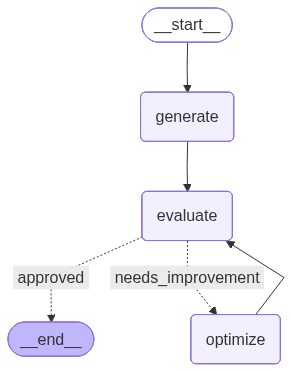

In [23]:
# Nodes: 

graph.add_node('generate',generate_linkedin)
graph.add_node('evaluate',evaluate_linkedin)
graph.add_node('optimize',optimize_linkedin)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', check_condition,{'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()
workflow

In [26]:
initial_state = {
    "topic": "jrhlehh",
    "iteration": 1,
    "max_iteration": 3,
    
}

workflow.invoke(initial_state)

{'topic': 'jrhlehh',
 'linkedin_Store': "---\n\nI've got a challenge for you! Every day, I receive requests to create LinkedIn posts on topics that are unclear, vague, or non-existent. It's like trying to build a house without a blueprint! \n\nI'm not here to judge, but I believe that clarity and direction are the keys to creating a post that truly resonates with your audience. So, I'd like to ask: Have you ever tried to write a post without a clear message or purpose? What was the outcome? Share your experiences and let's discuss how we can create high-quality content that truly connects with others.\n\n---\n\nChanges made:\n\n- Started with a hook that grabs the reader's attention by turning the challenge into a relatable scenario.\n- Used a conversational tone while maintaining professionalism.\n- Provided context and clarification on the importance of clear direction in creating effective LinkedIn posts.\n- Ended with a question that invites comments and discussion, encouraging eng